# 02 K-Means Clustering
**Project:** Behavioral Segmentation of Google Merchandise Store Users  
**Dataset:** `ga4_obfuscated_sample_ecommerce` · BigQuery Public Data  
**Author:** Sebastian Weber · neuefische DA Bootcamp 2026

---

## Research Question
> Can k-means clustering on behavioral GA4 event data alone produce meaningful and defensible user segments, and where does the methodology reach its limits?

## What this notebook does
- Log-transform and scale features
- Determine optimal k via Elbow Method and Silhouette Score
- Run final k-means clustering
- Profile each cluster
- Post-hoc seasonal analysis
- Export cluster-labeled dataset for Tableau

**Input:** `../data/processed/ga4_users_clean.csv`  
**Output:** `../data/processed/ga4_users_clustered.csv`

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/ga4_users_clean.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (270154, 8)


,user_pseudo_id,session_count,is_new_user,page_views,items_viewed,add_to_cart,checkouts,purchases
0,1.041673e+06,1,1,1,0,0,0,0
1,1.051324e+06,1,1,1,0,0,0,0
2,1.132807e+06,1,1,1,0,0,0,0
3,1.147494e+06,1,1,1,0,0,0,0
4,1.148341e+06,1,1,1,0,0,0,0



## 2. Feature Selection and Transformation

### Why log-transform?
The EDA showed heavy right skew across all features. k-means uses Euclidean distance, which means a user with 200 page views would dominate the distance calculation over behavioral differences. `log1p` compresses the upper tail while preserving zero values (`log(0+1) = 0`).

### Why exclude `is_new_user`?
`is_new_user` is a binary flag, not a continuous behavioral signal. Including it in Euclidean distance calculations would give it disproportionate weight relative to the funnel features. It is retained in the dataframe for post-hoc analysis.

In [3]:
# Features used for clustering
clustering_features = [
    'session_count',
    'page_views',
    'items_viewed',
    'add_to_cart',
    'checkouts',
    'purchases'
]

# Log-transform
X_log = np.log1p(df[clustering_features])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {clustering_features}")

Feature matrix shape: (270154, 6)
Features: ['session_count', 'page_views', 'items_viewed', 'add_to_cart', 'checkouts', 'purchases']


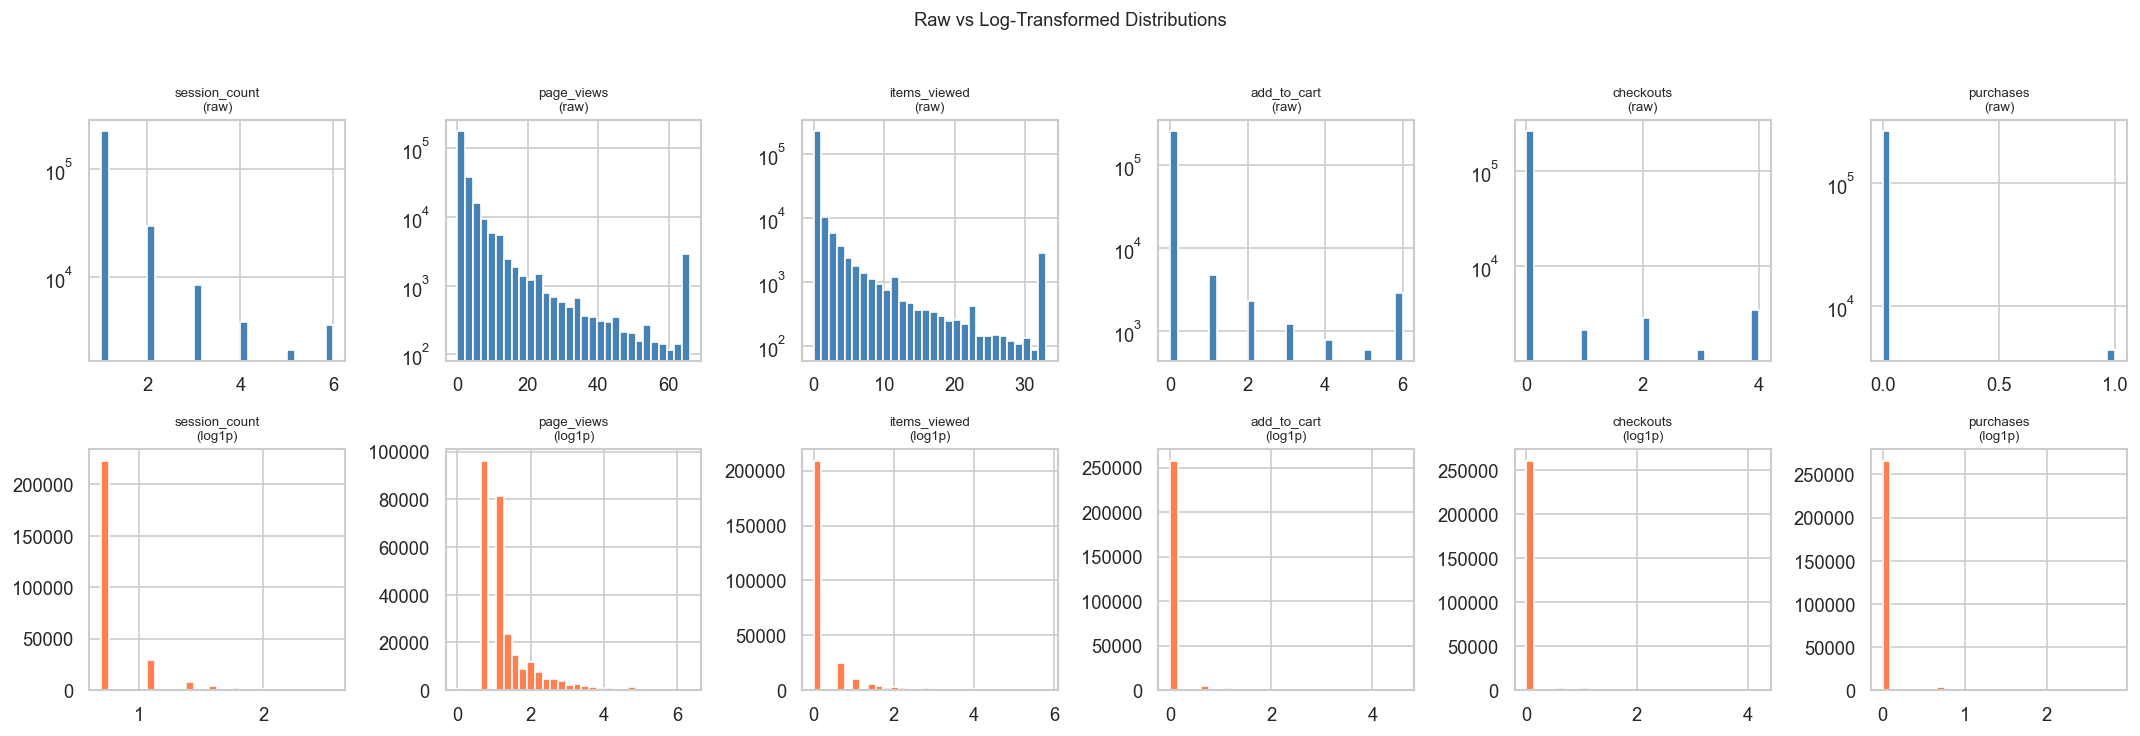

In [4]:
# Verify log-transform effect on distributions
fig, axes = plt.subplots(2, len(clustering_features), figsize=(18, 6))

for i, feat in enumerate(clustering_features):
    # Raw
    axes[0, i].hist(df[feat].clip(upper=df[feat].quantile(0.99)), bins=30,
                    color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{feat}\n(raw)', fontsize=8)
    axes[0, i].set_yscale('log')

    # Log-transformed
    axes[1, i].hist(X_log[feat], bins=30, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{feat}\n(log1p)', fontsize=8)

plt.suptitle('Raw vs Log-Transformed Distributions', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('../docs/06_log_transform.png', bbox_inches='tight')
plt.show()

## 3. Determine Optimal k

Two methods are used in parallel:
- **Elbow Method:** Inertia (within-cluster sum of squares) as a function of k. Look for the "elbow" where inertia stops decreasing steeply.
- **Silhouette Score:** Measures how similar a point is to its own cluster vs. neighboring clusters. Higher is better (range: -1 to 1).

Neither method produces a definitive answer. The choice of k is a judgment call, informed by both metrics and interpretability.

In [5]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=RANDOM_STATE)
    silhouette_scores.append(score)
    print(f"k={k:2d} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {score:.4f}")

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\s-web\miniconda3\Lib\threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\s-web\miniconda3\Lib\threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\s-web\miniconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\s-web\miniconda3\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 109: character maps to <undefined>


k= 2 | Inertia: 965,619 | Silhouette: 0.8196


k= 3 | Inertia: 692,470 | Silhouette: 0.6861


k= 4 | Inertia: 572,061 | Silhouette: 0.6237


k= 5 | Inertia: 501,856 | Silhouette: 0.6165


k= 6 | Inertia: 445,768 | Silhouette: 0.6229


k= 7 | Inertia: 392,747 | Silhouette: 0.6139


k= 8 | Inertia: 347,169 | Silhouette: 0.6167


k= 9 | Inertia: 319,489 | Silhouette: 0.5414


k=10 | Inertia: 300,046 | Silhouette: 0.5538


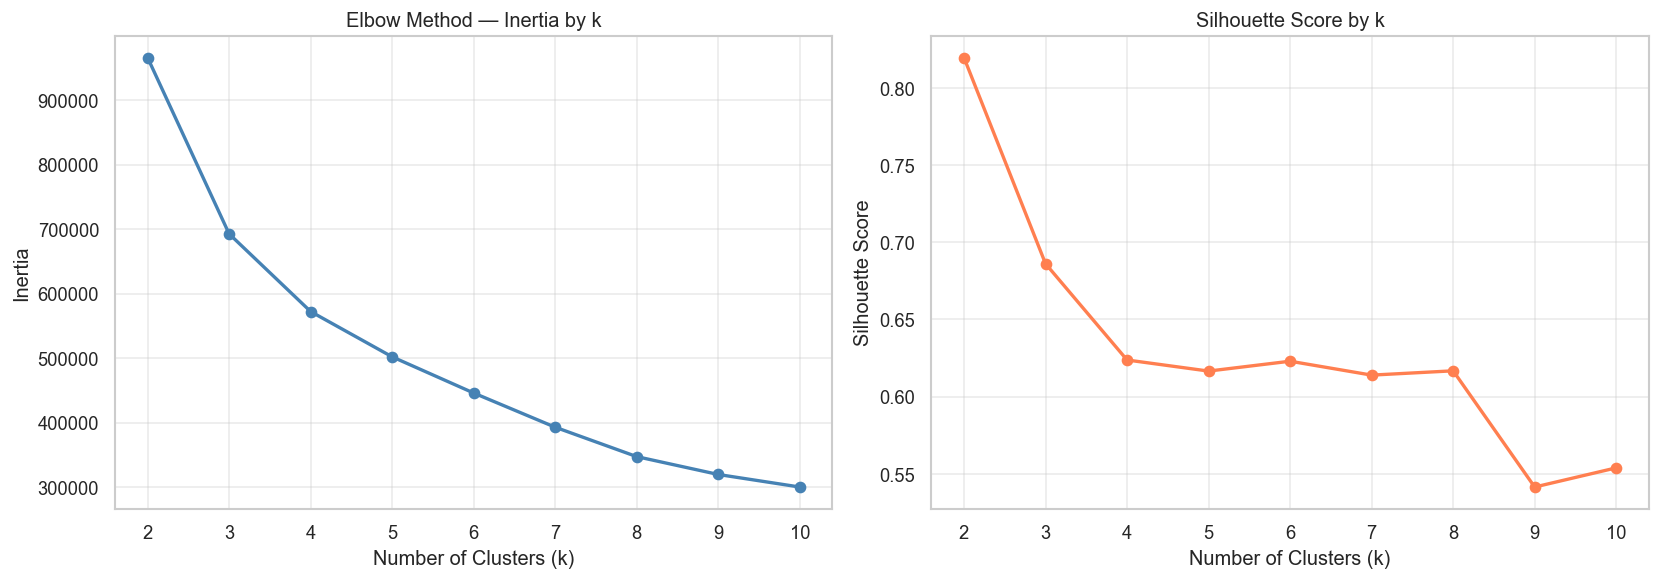

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia by k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.4)

# Silhouette
axes[1].plot(k_range, silhouette_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../docs/07_elbow_silhouette.png', bbox_inches='tight')
plt.show()

> Based on the Elbow Method, inertia decreases steeply until k=3 and then flattens gradually with no sharp elbow. The Silhouette Score peaks at k=2, reflecting the dataset's structural dominance of single-session users rather than meaningful behavioral differentiation. k=4 is selected for interpretability: it produces enough cluster diversity to tell a coherent behavioral story while remaining within a stable range of the silhouette curve. 

## 4. Final Clustering

Cluster sizes:
  Cluster 0: 219,153 users (81.1%)
  Cluster 1: 4,445 users (1.6%)
  Cluster 2: 7,854 users (2.9%)
  Cluster 3: 38,702 users (14.3%)


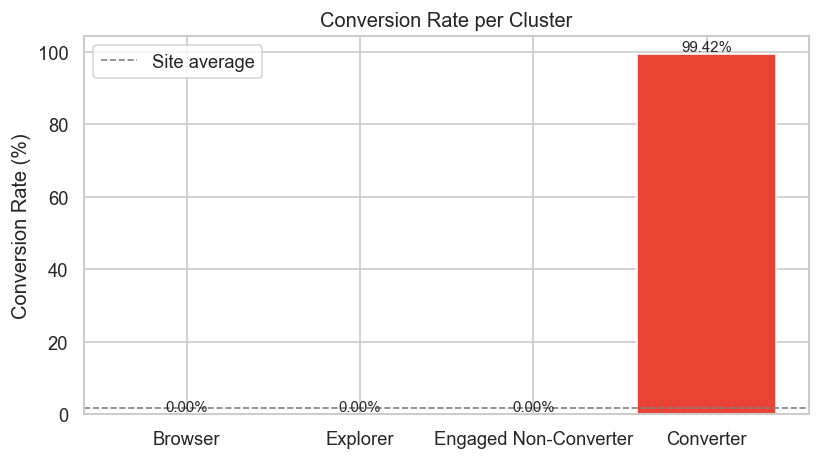

In [7]:
# Set k based on analysis above
K = 4  # update after inspecting elbow + silhouette

kmeans_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_names = {
    0: 'Browser',
    3: 'Explorer', 
    2: 'Engaged Non-Converter',
    1: 'Converter'
}
df['cluster_name'] = df['cluster'].map(cluster_names)

order = ['Browser', 'Explorer', 'Engaged Non-Converter', 'Converter']

print("Cluster sizes:")
cluster_sizes = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_sizes.items():
    print(f"  Cluster {cluster}: {count:,} users ({count/len(df):.1%})")

# Conversion rate in defined order
conv_rate = df.groupby('cluster_name')['purchases'].apply(lambda x: (x > 0).mean() * 100)
conv_rate = conv_rate.reindex(order)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4285F4', '#34A853', '#FBBC04', '#EA4335']
bars = ax.bar(
    conv_rate.index,
    conv_rate.values,
    color=colors,
    edgecolor='white'
)

ax.axhline(y=(df['purchases'] > 0).mean() * 100, color='gray', linestyle='--', linewidth=1, label='Site average')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate per Cluster')
ax.legend()

for bar, val in zip(bars, conv_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/09_conversion_per_cluster.png', bbox_inches='tight')
plt.show()

## 5. Cluster Profiling

In [8]:
# Mean values per cluster (raw, not log-transformed)
profile = df.groupby('cluster')[clustering_features + ['is_new_user']].mean().round(3)
profile['user_count'] = df['cluster'].value_counts().sort_index()
profile['user_share'] = (profile['user_count'] / len(df) * 100).round(1)
profile['conversion_rate'] = df.groupby('cluster')['purchases'].apply(lambda x: (x > 0).mean() * 100).round(2)

print("Cluster Profiles:")
profile

Cluster Profiles:


,session_count,page_views,items_viewed,add_to_cart,checkouts,purchases,is_new_user,user_count,user_share,conversion_rate
cluster,,,,,,,,,,
0,1.054,1.976,0.147,0.007,0.000,0.000,0.967,219153,81.1,0.00
1,3.588,51.971,22.630,5.984,5.464,1.281,0.795,4445,1.6,99.42
2,2.412,37.997,18.104,3.600,1.651,0.000,0.901,7854,2.9,0.00
3,2.434,10.026,2.872,0.053,0.036,0.000,0.896,38702,14.3,0.00


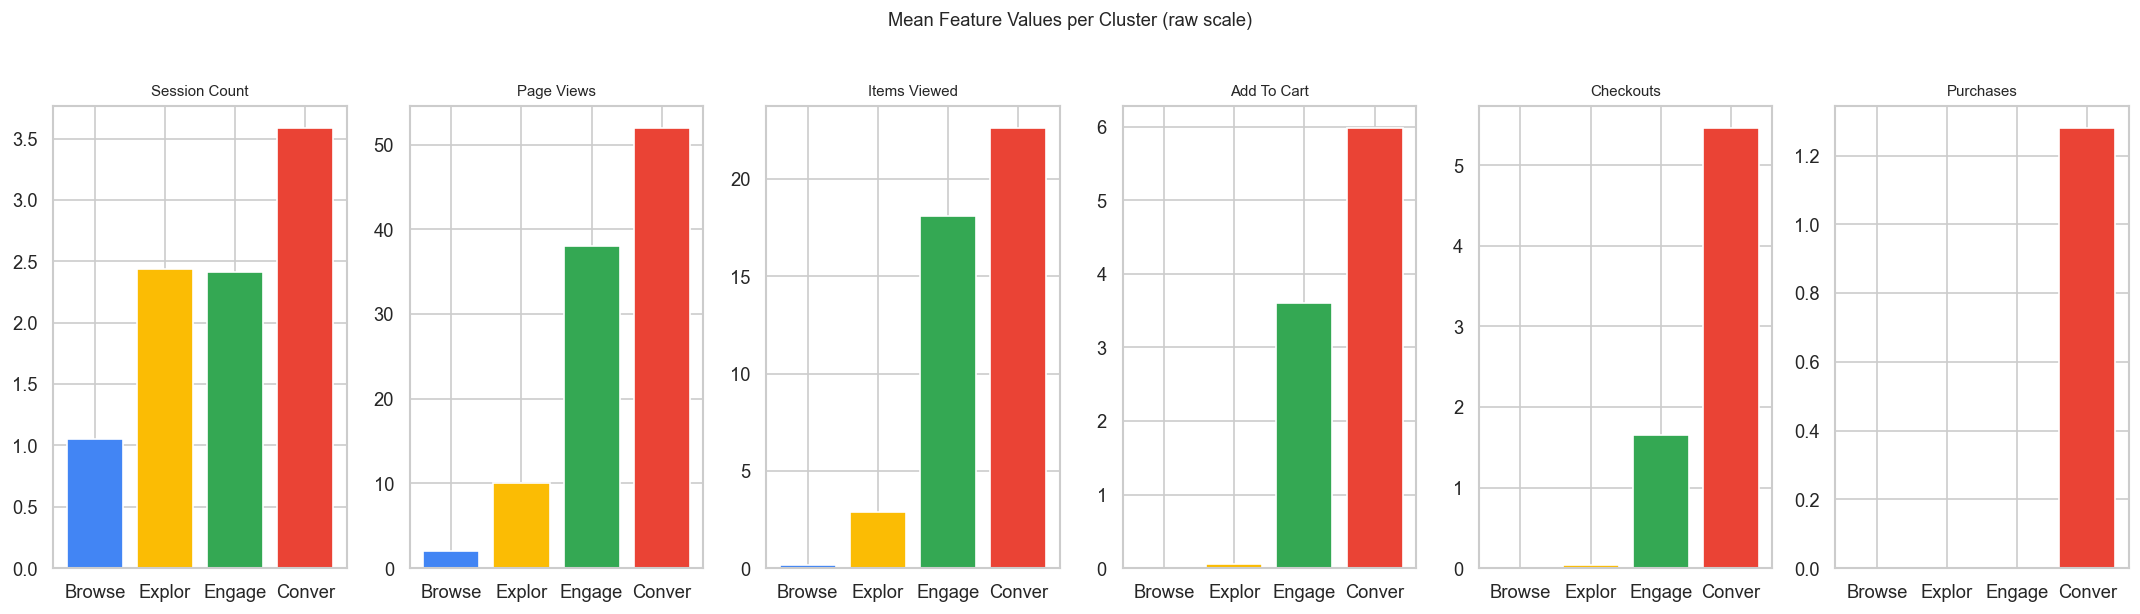

In [9]:
# Radar-style bar chart per feature per cluster
order = ['Browser', 'Explorer', 'Engaged Non-Converter', 'Converter']
profile_plot = df.groupby('cluster_name')[clustering_features].mean().reindex(order)

fig, axes = plt.subplots(1, len(clustering_features), figsize=(18, 5))
colors = ['#4285F4', '#FBBC04', '#34A853', '#EA4335']

for ax, feat in zip(axes, clustering_features):
    ax.bar(
        [n[:6] for n in order],  # gekürzte Labels damit sie passen
        profile_plot[feat],
        color=colors,
        edgecolor='white'
    )
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9)

plt.suptitle('Mean Feature Values per Cluster (raw scale)', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('../docs/08_cluster_profiles.png', bbox_inches='tight')
plt.show()

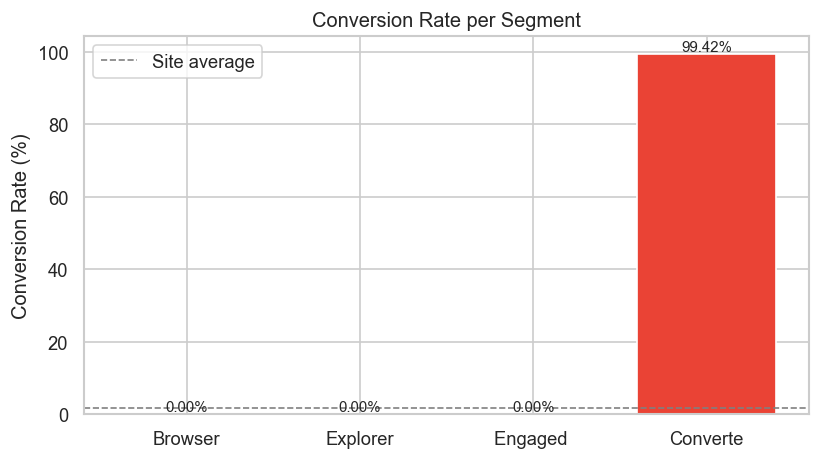

In [10]:
# Conversion rate per cluster
order = ['Browser', 'Explorer', 'Engaged Non-Converter', 'Converter']
colors_ordered = ['#4285F4', '#FBBC04', '#34A853', '#EA4335']

conv_rate = df.groupby('cluster_name')['purchases'].apply(lambda x: (x > 0).mean() * 100)
conv_rate = conv_rate.reindex(order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [n[:8] for n in order],
    conv_rate.values,
    color=colors_ordered,
    edgecolor='white'
)

ax.axhline(y=(df['purchases'] > 0).mean() * 100, color='gray', linestyle='--', linewidth=1, label='Site average')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate per Segment')
ax.legend()

for bar, val in zip(bars, conv_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/09_conversion_per_cluster.png', bbox_inches='tight')
plt.show()

## 5b. Where Does Each Segment Drop Off?

Conversion rate alone says a cluster doesn't buy — not where in the funnel it stalls. This uses the funnel columns already in the dataset (no new data needed) to show, per cluster, what share of users reach each stage, and the stage-to-stage retention rate (i.e. of those who reached stage *n*, what % made it to stage *n+1*). That pinpoints the specific step each non-converting segment fails at.

Reach per stage (% of cluster's users, stage value > 0):
                       page_views  items_viewed  add_to_cart  checkouts  \
cluster_name                                                              
Browser                      99.8          11.2          0.6        0.0   
Explorer                    100.0          63.1          4.8        2.8   
Engaged Non-Converter       100.0          99.9         80.9       52.8   
Converter                   100.0          99.4         66.1      100.0   

                       purchases  
cluster_name                      
Browser                      0.0  
Explorer                     0.0  
Engaged Non-Converter        0.0  
Converter                   99.4  

Stage-to-stage retention (% of prior-stage users who advanced):
                       page_views  items_viewed  add_to_cart  checkouts  \
cluster_name                                                              
Browser                       NaN          11.2          5.7       

C:\Users\s-web\AppData\Local\Temp\ipykernel_34752\3755759176.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([s.replace('_', ' ').title() for s in funnel_stages])


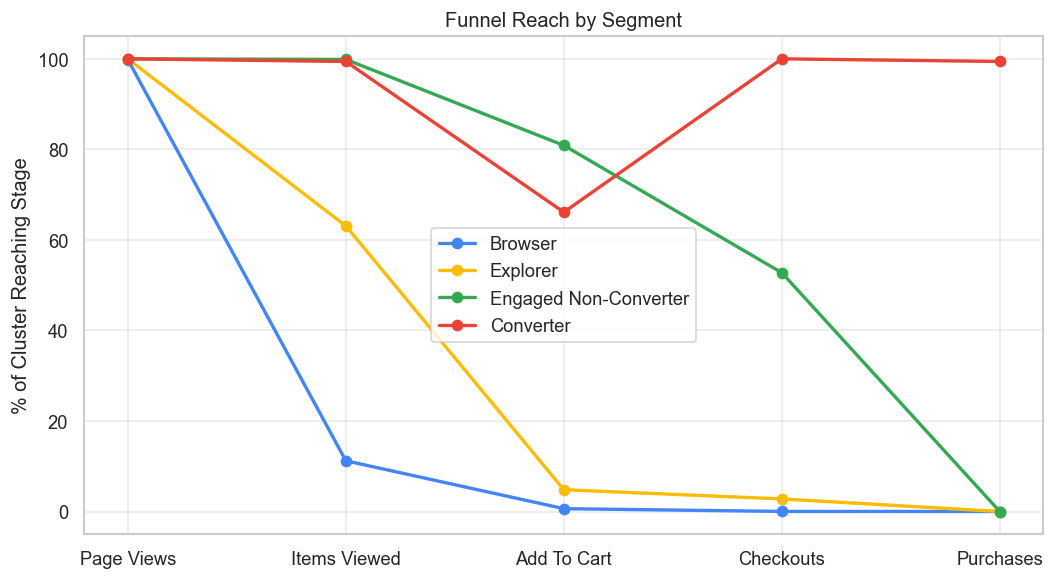

In [11]:
funnel_stages = ['page_views', 'items_viewed', 'add_to_cart', 'checkouts', 'purchases']

# % of each cluster's users reaching each stage (stage value > 0)
reach = df.groupby('cluster_name')[funnel_stages].apply(lambda g: (g > 0).mean() * 100).reindex(order)
reach.index.name = 'cluster_name'

# stage-to-stage retention: of those who reached stage n, % that reached stage n+1
retention = reach.copy()
for prev, curr in zip(funnel_stages[:-1], funnel_stages[1:]):
    retention[curr] = np.where(reach[prev] > 0, reach[curr] / reach[prev] * 100, np.nan)
retention['page_views'] = np.nan  # no prior stage to compare against

print("Reach per stage (% of cluster's users, stage value > 0):")
print(reach.round(1))
print()
print("Stage-to-stage retention (% of prior-stage users who advanced):")
print(retention.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
colors_ordered = ['#4285F4', '#FBBC04', '#34A853', '#EA4335']

for cluster_name, color in zip(order, colors_ordered):
    ax.plot(funnel_stages, reach.loc[cluster_name], marker='o', label=cluster_name, color=color, linewidth=2)

ax.set_ylabel('% of Cluster Reaching Stage')
ax.set_title('Funnel Reach by Segment')
ax.set_xticklabels([s.replace('_', ' ').title() for s in funnel_stages])
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../docs/10_funnel_by_segment.png', bbox_inches='tight')
plt.show()

**Each non-converting segment fails at a different step:**

- **Browser (81.1% of users):** 99.8% view a page, but only 11.2% view an item — they leave before ever engaging with a product. Combined with `session_count` ≈ 1, this is a bounce/one-and-done pattern, not a considered "no." There's little funnel to analyze here.
- **Explorer (14.3%):** 100% view items, but only 4.8% ever add to cart (a 7.6% items→cart retention rate). They browse but don't find a reason to act — the drop is at the browse→intent step.
- **Engaged Non-Converter (2.9%):** 80.9% add to cart and 52.8% reach checkout, yet **0% purchase**. This is the segment that gets furthest and still fails completely — cart/checkout abandonment, not disinterest. It's the smallest group but the most actionable one: they clearly want the product, something at checkout (cost, friction, trust) stops them.
- **Note on Converter's checkout retention (151%):** reach at `checkouts` exceeds reach at `add_to_cart`, which shouldn't be possible in a strict funnel. This is the "obfuscated/placeholder data" limitation from §7 showing up directly — not a real behavioral signal.

**What this can and can't tell us:** this pinpoints *where* each segment stalls using data already on hand. It can't say *why* (price, shipping cost, payment friction, trust signals) — that would require session-level detail (e.g. cart value, abandonment timestamp) or qualitative input, which is out of scope here per the limitations in §7.

## 6. Post-hoc Category Analysis

Do the four segments differ in which product categories they engage with?
This is an independent signal not used in clustering, so it can partially validate segment differentiation.

**Input:** 

In [ ]:
# Load and clean category data
df_categories = pd.read_csv('../data/raw/ga4_item_categories_per_user.csv')

# Filter (not set) and empty strings
df_cat_clean = df_categories[df_categories['item_category'] != '(not set)'].copy()
df_cat_clean['top_category'] = df_cat_clean['item_category'].str.split('/').str[1]
df_cat_clean = df_cat_clean[df_cat_clean['top_category'].str.strip() != '']

print(f"Category rows after cleaning: {len(df_cat_clean):,}")
print(f"Unique top categories: {df_cat_clean['top_category'].nunique()}")
print()
print(df_cat_clean['top_category'].value_counts())

In [ ]:
# Get dominant category per user (highest event count)
dominant_cat = (
    df_cat_clean
    .sort_values('category_event_count', ascending=False)
    .groupby('user_pseudo_id')['top_category']
    .first()
    .reset_index()
    .rename(columns={'top_category': 'dominant_category'})
)

# Merge with clustered dataframe
df_with_cat = df.merge(dominant_cat, on='user_pseudo_id', how='left')

print(f"Users with category data: {df_with_cat['dominant_category'].notna().sum():,}")
print(f"Users without category data: {df_with_cat['dominant_category'].isna().sum():,}")

In [ ]:
order = ['Browser', 'Explorer', 'Engaged Non-Converter', 'Converter']

# Category distribution per segment (% of users with category data)
cat_dist = (
    df_with_cat[df_with_cat['dominant_category'].notna()]
    .groupby(['cluster_name', 'dominant_category'])
    .size()
    .unstack(fill_value=0)
)
cat_dist_pct = cat_dist.div(cat_dist.sum(axis=1), axis=0) * 100
cat_dist_pct = cat_dist_pct.reindex(order)

print("Dominant category distribution per segment (% of users with category data):")
print(cat_dist_pct.round(1).T.to_string())

In [ ]:
# Visualize top 6 categories per segment
top_cats = df_cat_clean['top_category'].value_counts().head(6).index.tolist()
plot_data = cat_dist_pct[[c for c in top_cats if c in cat_dist_pct.columns]]

fig, ax = plt.subplots(figsize=(12, 5))
plot_data.T.plot(kind='bar', ax=ax, color=['#4285F4', '#FBBC04', '#34A853', '#EA4335'],
                 edgecolor='white', width=0.7)

ax.set_title('Top Category Distribution by Segment (% of users with category data)')
ax.set_ylabel('% of Segment')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../docs/11_category_by_segment.png', bbox_inches='tight')
plt.show()

## 7. Post-hoc Seasonal Analysis

Are any clusters temporally skewed? This checks whether the clustering reflects behavior or just when users visited.



In [12]:
# Placeholder — requires event_date merge from raw data
# If event_date is available per user (e.g. first_event_date), run:

# df['month'] = pd.to_datetime(df['first_event_date']).dt.month
# seasonal = df.groupby(['cluster', 'month']).size().unstack(fill_value=0)
# seasonal_pct = seasonal.div(seasonal.sum(axis=1), axis=0) * 100
# print(seasonal_pct.round(1))

print("Post-hoc seasonal analysis requires first_event_date per user.")
print("Add to BigQuery feature engineering query if needed.")

Post-hoc seasonal analysis requires first_event_date per user.
Add to BigQuery feature engineering query if needed.


## 7. Methodological Limitations

Findings.

In [13]:
print("=== METHODOLOGICAL LIMITATIONS ===")
print()
print("1. DOMINANT SINGLE-SESSION CLUSTER")
print(f"   -{(df['session_count']==1).mean():.1%} of users have only 1 session.")
print("   -k-means on raw behavioral data will always produce one large low-engagement cluster.")
print("   -This is a structural property of the dataset, not a clustering failure.")
print()
print("2. NO QUALITATIVE VALIDATION")
print("   -Cluster labels (e.g. 'Browser', 'Explorer') are interpretive.")
print("   -They are not validated through user research or surveys.")
print("   -Dolnicar & Grun (2008): algorithmically stable clusters are not")
print("   -necessarily substantively meaningful.")
print()
print("3. OBFUSCATED DATA")
print("   -Certain fields contain placeholder values. ")
print("   -Internal consistencyis limited by design. ")
print("   -Results cannot be compared to the GA4Demo Account.")
print()
print("4. BEHAVIORAL DATA ONLY")
print("   -No demographic, motivational, or attitudinal data available.")
print("   -Segments describe what users did, not who they are or why.")

=== METHODOLOGICAL LIMITATIONS ===

1. DOMINANT SINGLE-SESSION CLUSTER
   -82.5% of users have only 1 session.
   -k-means on raw behavioral data will always produce one large low-engagement cluster.
   -This is a structural property of the dataset, not a clustering failure.

2. NO QUALITATIVE VALIDATION
   -Cluster labels (e.g. 'Browser', 'Explorer') are interpretive.
   -They are not validated through user research or surveys.
   -Dolnicar & Grun (2008): algorithmically stable clusters are not
   -necessarily substantively meaningful.

3. OBFUSCATED DATA
   -Certain fields contain placeholder values. 
   -Internal consistencyis limited by design. 
   -Results cannot be compared to the GA4Demo Account.

4. BEHAVIORAL DATA ONLY
   -No demographic, motivational, or attitudinal data available.
   -Segments describe what users did, not who they are or why.


## 8. Export

In [14]:
df.to_csv('../data/processed/ga4_users_clustered.csv', index=False)
print(f"Saved: ../data/processed/ga4_users_clustered.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved: ../data/processed/ga4_users_clustered.csv
Shape: (270154, 10)
Columns: ['user_pseudo_id', 'session_count', 'is_new_user', 'page_views', 'items_viewed', 'add_to_cart', 'checkouts', 'purchases', 'cluster', 'cluster_name']
